1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


C:\Users\Utente\AppData\Local\Temp\ipykernel_4676\2696621611.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(KDE,l)


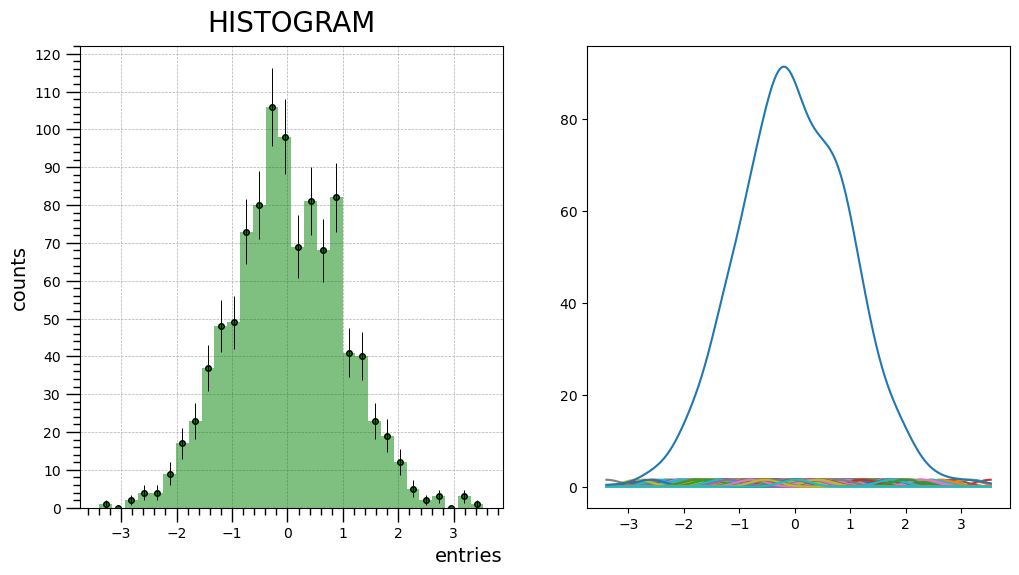

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
import scipy as sp


N = 1000
x = np.random.normal(0,1,N)
#print(x)
fig, (ax,ax1) = plt.subplots(nrows = 1, ncols = 2, figsize=(12, 6))
n,bins,_ = ax.hist(x,30, histtype = 'stepfilled', alpha = 0.5, color = 'green', zorder=2)

ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(AutoMinorLocator(5))

ax.tick_params(which='major', width=1.0)
ax.tick_params(which='major', length=10)
ax.tick_params(which='minor', width=1.0, labelsize=10)
ax.tick_params(which='minor', length=5, labelsize=10, labelcolor='0.25')

ax.grid(linestyle="--", linewidth=0.5, zorder=1)

ax.set_title("HISTOGRAM", fontsize=20, verticalalignment='bottom')
ax.set_xlabel("entries", fontsize = 14, loc = "right")
ax.set_ylabel("counts", fontsize = 14, loc = "center")

values = []
errors = []
for i in range(len(n)):
    values.append((bins[i+1]+bins[i])/2)
    errors.append(np.sqrt(n[i]))
ax.plot(values, n, linewidth=0,marker='o', markerfacecolor='g', markeredgecolor='k', markersize = 4)
ax.errorbar(values,n,errors, fmt = 'none', ecolor = 'k', barsabove = False, elinewidth = 0.7)

std = 1.06*x.std()*len(x)**(-1/5)
l = np.linspace(x.min(),x.max(),1000)
KDE = np.zeros(1000)
for elem in x:
    pdf = sp.stats.norm.pdf(l, loc = elem, scale = std)
    ax1.plot(l,pdf)
    KDE = KDE + pdf

A = np.sum(n)*(bins[1]-bins[0])
I = np.trapz(KDE,l)
KDE = KDE*A/I
ax1.plot(l,KDE)
plt.show()

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

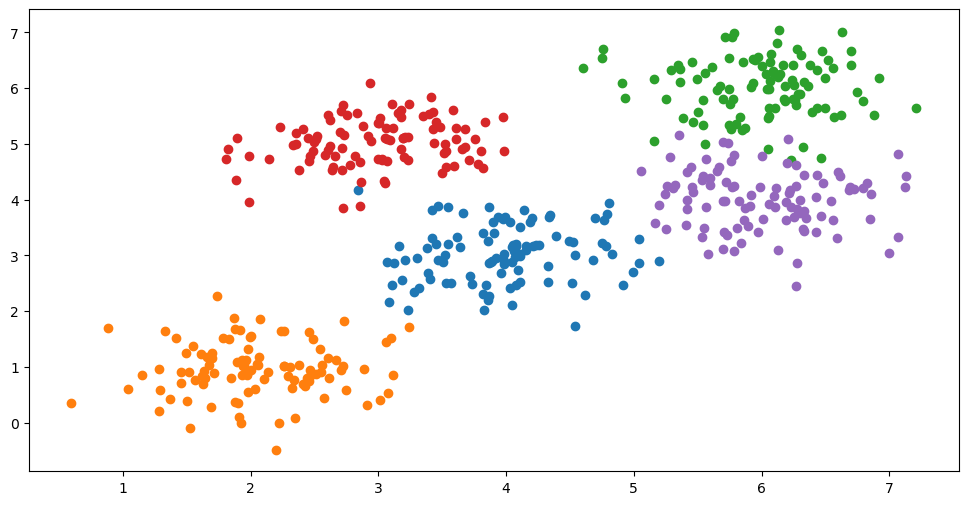

In [2]:
import numpy as np
import numpy.random as npr

N = 5
fig, ax = plt.subplots(figsize=(12, 6))
for i in range(N):
    xmean = npr.randint(1,7)
    ymean = npr.randint(1,7)
    x = npr.normal(loc = xmean, scale = 0.5, size = 100)
    y = npr.normal(loc = ymean, scale = 0.5, size = 100)
    ax.scatter(x,y)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import matplotlib.pyplot as plt

a = np.load('residuals_261.npy', allow_pickle=True).item()
df = pd.DataFrame(a)
mask = np.abs(df['residuals']) < 2
df = df[mask]
slope, intercept, r, p, se = scipy.stats.linregress(df['distances'], df['residuals'])
print("slope: ", slope)
print("intercept: ", intercept)
sns.jointplot(x="distances", y="residuals", data=df, kind = 'reg', color = 'red', 
             scatter_kws={"s": 1, "alpha": 0.5}, line_kws = {"color" : "black", "linewidth" : 1})
bins = np.arange(0,21,2)
x = np.arange(1,20,2)
mean = []
err = []
for i in range(1, len(bins)):
    mask1 = df['distances'] < bins[i]
    mask2 = df['distances'] > bins[i-1]
    auxdf = df[mask1 & mask2]
    mean.append(auxdf['residuals'].mean())
    err.append(auxdf['residuals'].std())
plt.errorbar(x,mean,err, color = 'black', linestyle = '')
plt.scatter(x,mean, color = 'black')

slope:  0.0032597701220305835
intercept:  -0.15432816763069473
